# Exploration Data Analysis
This notebook explores the cleaned 5-minute window summary dataset. The goal is to understand the distribution of the target variable, identify which features correlate most strongly with occupancy, and justify the modelling approach taken in this project.

In [268]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_pickle("../data/processed/df.pkl")

## Dataset overview

The cleaned dataset contains 144 five-minute observation windows across three environments, with 16 columns covering probe-based features, MAC address metrics, room capacity, and two target variables — raw headcount and occupancy ratio.

In [269]:
print(df.shape)
print(df.dtypes)
df.describe()

(144, 16)
timestamp               float64
total_probes              int64
probes_rssi_55            int64
probes_rssi_60            int64
probes_rssi_65            int64
probes_rssi_70            int64
probes_rssi_75            int64
probes_rssi_80            int64
unique_mac_addresses      int64
unique_mac_2plus          int64
unique_mac_3plus          int64
unique_mac_4plus          int64
unique_mac_5plus          int64
max_capacity              int64
ground_truth_people       int64
occupancy_ratio         float64
dtype: object


,timestamp,total_probes,probes_rssi_55,probes_rssi_60,probes_rssi_65,probes_rssi_70,probes_rssi_75,probes_rssi_80,unique_mac_addresses,unique_mac_2plus,unique_mac_3plus,unique_mac_4plus,unique_mac_5plus,max_capacity,ground_truth_people,occupancy_ratio
count,1.440000e+02,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,1.788018e+09,1226.645833,169.562500,310.409722,503.027778,689.506944,852.798611,992.444444,548.875000,189.958333,76.048611,50.305556,35.722222,135.444444,40.680556,0.303447
std,3.828904e+05,737.791246,163.053027,265.162819,383.986359,517.597246,629.890395,699.997870,405.159019,128.061004,50.810539,32.268601,22.167337,162.702860,54.237325,0.187863
min,1.787343e+09,359.000000,4.000000,14.000000,43.000000,54.000000,83.000000,128.000000,85.000000,32.000000,12.000000,9.000000,7.000000,40.000000,4.000000,0.080000
25%,1.787697e+09,681.250000,35.750000,87.250000,156.750000,232.500000,299.500000,418.250000,268.250000,96.750000,40.000000,26.000000,19.000000,50.000000,8.000000,0.153333
50%,1.788244e+09,965.500000,96.000000,253.500000,406.000000,595.500000,697.500000,820.000000,384.500000,155.000000,58.500000,36.500000,27.000000,65.000000,23.500000,0.240000
75%,1.788364e+09,1685.500000,264.000000,435.250000,748.000000,1048.000000,1241.250000,1315.250000,760.750000,243.250000,94.000000,68.250000,50.000000,70.000000,47.250000,0.415385
max,1.788458e+09,3678.000000,682.000000,1104.000000,1640.000000,2081.000000,2826.000000,3339.000000,1834.000000,587.000000,240.000000,147.000000,102.000000,600.000000,302.000000,0.771429


## Target variable analysis

- Raw headcount shows a heavily right-skewed distribution with a long tail reaching 300 people. The log-transformed view better reveals the multimodal nature of the data, reflecting multiple different collection environments — the same probe count can mean very different things depending on room size, making a single model impossible to calibrate.

- Normalizing by room capacity produces an occupancy ratio (0–1) that collapses the distributions onto a common scale. The result is unimodal and right-skewed, reflecting that spaces spend more time at low-to-moderate occupancy than at full capacity.

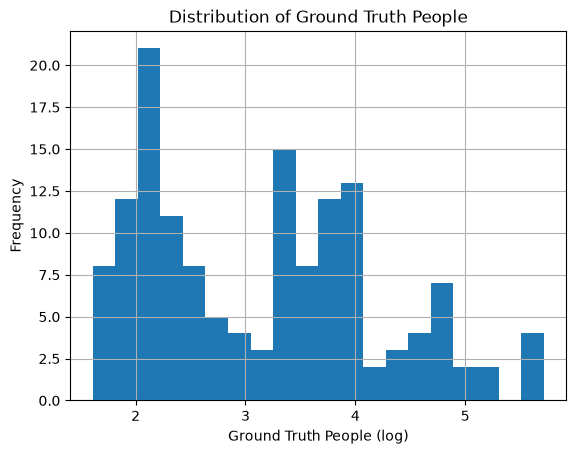

In [270]:
df['ground_truth_people'].apply(np.log1p).hist(bins=20)
plt.xlabel("Ground Truth People (log)")
plt.ylabel("Frequency")
plt.title("Distribution of Ground Truth People")
plt.show()

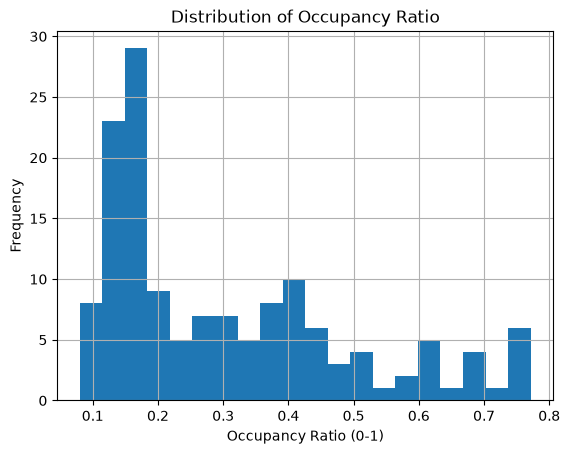

In [271]:
df['occupancy_ratio'].hist(bins=20)
plt.xlabel("Occupancy Ratio (0-1)")
plt.ylabel("Frequency")
plt.title("Distribution of Occupancy Ratio")
plt.show()


## Correlation analysis against features (Occupancy Ratio vs Raw Headcount)

- Features correlate substantially more strongly with raw headcount (mean Pearson 0.73) than occupancy ratio (mean Pearson 0.42), confirming that probe signals are fundamentally absolute presence detectors rather than relative busyness sensors.

- RSSI threshold ranking inverts between targets — loose filters (-80 dBm) lead against headcount (0.87) while tight filters (-65 dBm) lead against occupancy ratio (0.64). 

- This reflects the physics of probe capture: nearby devices scale with absolute presence, while wider-area signals better reflect environmental busyness relative to capacity.

- Unique MAC features drop sharply against occupancy ratio (0.27 vs 0.86 for `unique_mac_2plus`), suggesting MAC-based metrics carry little information about relative busyness and may be dropped from the ratio-predicting component of the model.

- Spearman consistently exceeds Pearson against occupancy ratio (mean gap 0.15), confirming non-linear relationships that motivate a Random Forest approach when considering `occupancy_ratio` as the target variable. 

- `max_capacity` shows near-zero correlation with occupancy ratio (-0.02), confirming normalisation successfully removed room-size bias from the target.


In [272]:
exclude = ['occupancy_ratio', 'ground_truth_people', 'timestamp', 'log_headcount']
features = [col for col in df.columns if col not in exclude]

pearson_ratio = df[features + ['occupancy_ratio']].corr(method='pearson')['occupancy_ratio'].drop('occupancy_ratio')
spearman_ratio = df[features + ['occupancy_ratio']].corr(method='spearman')['occupancy_ratio'].drop('occupancy_ratio')

pearson_headcount = df[features + ['ground_truth_people']].corr(method='pearson')['ground_truth_people'].drop('ground_truth_people')
spearman_headcount = df[features + ['ground_truth_people']].corr(method='spearman')['ground_truth_people'].drop('ground_truth_people')

corr_table_ratio = pd.DataFrame({
    'Pearson': pearson_ratio,
    'Spearman': spearman_ratio
}).sort_values('Pearson', ascending=False)

corr_table_headcount = pd.DataFrame({
    'Pearson': pearson_headcount,
    'Spearman': spearman_headcount
}).sort_values('Pearson', ascending=False)

print("--- Occupancy Ratio ---")
print(corr_table_ratio)
print(corr_table_ratio.describe())

print("\n--- Ground Truth Headcount ---")
print(corr_table_headcount)
print(corr_table_headcount.describe())

--- Occupancy Ratio ---
                       Pearson  Spearman
probes_rssi_65        0.639962  0.671447
probes_rssi_60        0.635046  0.650342
probes_rssi_70        0.616620  0.680735
probes_rssi_55        0.593005  0.582713
probes_rssi_75        0.573385  0.668156
probes_rssi_80        0.514598  0.637011
total_probes          0.379961  0.533703
unique_mac_5plus      0.376114  0.427385
unique_mac_4plus      0.330319  0.443065
unique_mac_3plus      0.292800  0.454703
unique_mac_addresses  0.280018  0.445806
unique_mac_2plus      0.268511  0.464114
max_capacity         -0.013823  0.509700
         Pearson   Spearman
count  13.000000  13.000000
mean    0.422040   0.551452
std     0.194538   0.100066
min    -0.013823   0.427385
25%     0.292800   0.454703
50%     0.379961   0.533703
75%     0.593005   0.650342
max     0.639962   0.680735

--- Ground Truth Headcount ---
                       Pearson  Spearman
total_probes          0.876316  0.837895
probes_rssi_80        0.872721  0.87

## Correlation heatmap

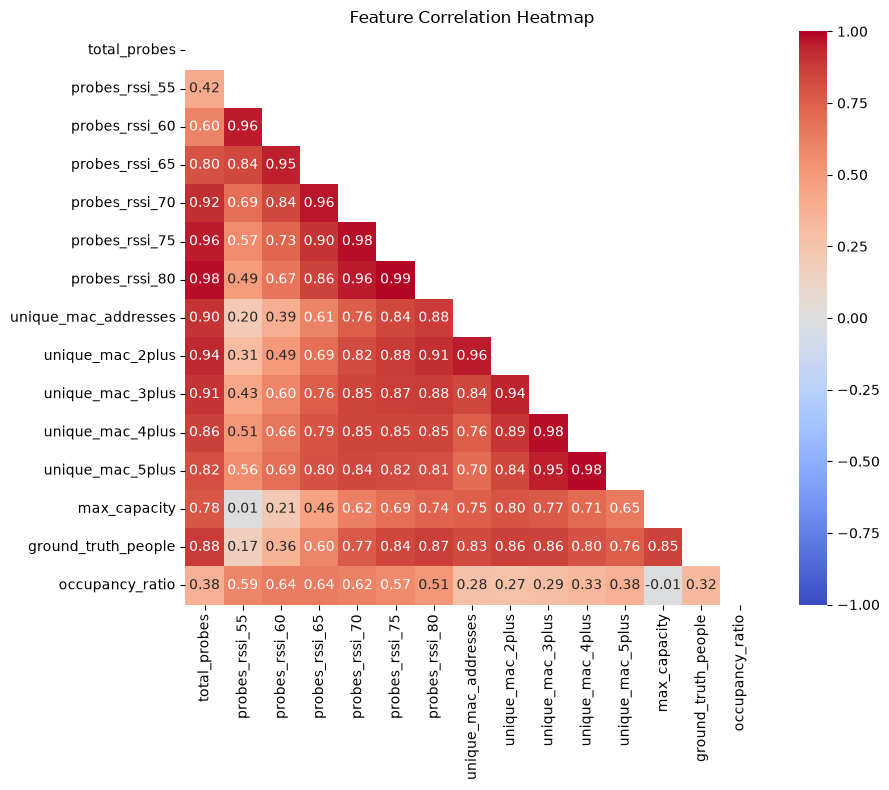

In [273]:
pearson_corr = df[features + ['ground_truth_people', 'occupancy_ratio']].corr(method='pearson')
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

- The heatmap reveals two clusters of highly intercorrelated features: probe RSSI threshold features (0.96-0.99) and MAC threshold features (0.84-0.98). Including multiple features from either cluster would introduce severe multicollinearity. 

- Based on correlation with the target, `probes_rssi_80` and `unique_mac_2plus` are retained as the representative features from each cluster.

- Notably, all features show substantially weaker correlation with `occupancy_ratio` than with raw `ground_truth_people`, suggesting the probe signal captures absolute presence better than relative busyness — a known limitation of probe-based sensing that will be monitored in model evaluation.


## Individual scatter plots

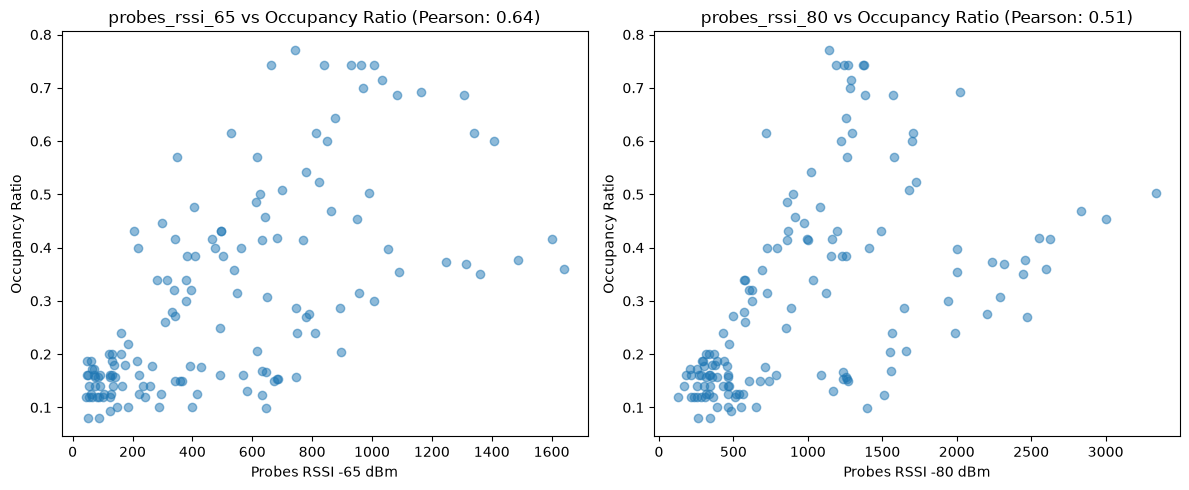

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['probes_rssi_65'], df['occupancy_ratio'], alpha=0.5)
axes[0].set_xlabel("Probes RSSI -65 dBm")
axes[0].set_ylabel("Occupancy Ratio")
axes[0].set_title(f"probes_rssi_65 vs Occupancy Ratio (Pearson: 0.64)")

axes[1].scatter(df['probes_rssi_80'], df['occupancy_ratio'], alpha=0.5)
axes[1].set_xlabel("Probes RSSI -80 dBm")
axes[1].set_ylabel("Occupancy Ratio")
axes[1].set_title(f"probes_rssi_80 vs Occupancy Ratio (Pearson: 0.51)")

plt.tight_layout()
plt.show()


- `probes_rssi_65` shows the strongest correlation with occupancy ratio (Pearson 0.64), outperforming tighter RSSI thresholds. The broader signal capture at -60 dBm better reflects environmental busyness relative to room capacity than nearby-device counts alone.
- Notably, `probes_rssi_80` — the strongest predictor of raw headcount (Pearson 0.87) — drops to 0.51 against occupancy ratio. This confirms that tight RSSI filters capture absolute presence well but are weaker indicators of how full a space is relative to its capacity.

## Residual pre-check

### Before normalization

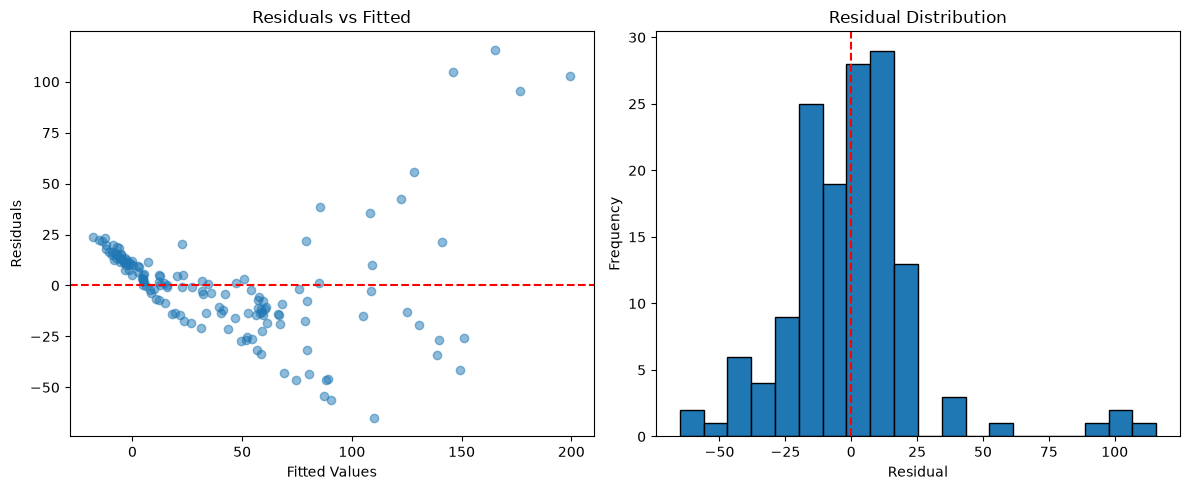

In [275]:
x = df["probes_rssi_80"]
y = df["ground_truth_people"]

coeffs = np.polyfit(x, y, 1)
predicted = np.polyval(coeffs, x)
residuals = y - predicted

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(predicted, residuals, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=20, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

### After normalization

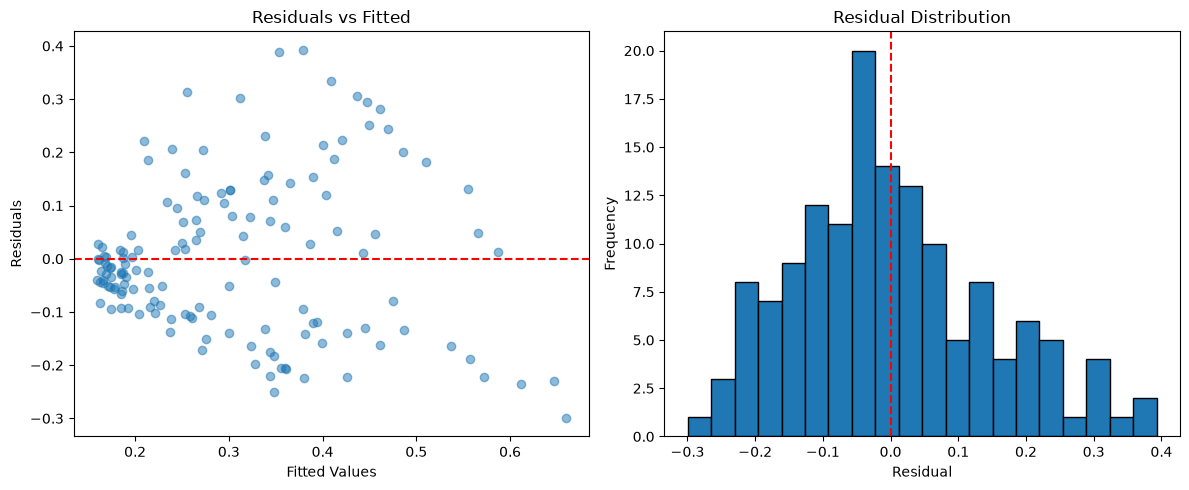

In [276]:
x = df["probes_rssi_65"]
y = df["occupancy_ratio"]

coeffs = np.polyfit(x, y, 1)
predicted = np.polyval(coeffs, x)
residuals = y - predicted

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(predicted, residuals, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=20, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

Normalizing by room capacity substantially reduced heteroscedasticity compared to raw headcount. However, residuals (comparing to strongest feature) remain right-skewed with a positive tail, and a mild pattern persists in the residuals vs fitted plot, suggesting residual non-linearity. This motivates evaluating non-linear models alongside linear regression in the modelling phase.

## Modelling justification

The following evidence collectively motivates a multi-output ensemble approach predicting both headcount and occupancy ratio simultaneously:

- **Non-linearity** — Spearman > Pearson consistently rules out pure linear regression as the primary model
- **Heteroscedasticity** — residual pre-check shows systematic bias that linear models cannot resolve
- **Multicollinearity** — Random Forest handles correlated features naturally without destabilising coefficients
- **Dual targets** — multi-output regression captures the strong headcount signal (0.87) and the generalisable ratio signal (0.64) simultaneously

The following models will be evaluated:

1. **Linear Regression** — baseline, establishes minimum performance
2. **Decision Tree** — simple non-linear baseline
3. **Random Forest** — primary model, handles non-linearity and multicollinearity naturally
4. **Stacking Ensemble (LR + RF)** — final model, combines linear precision with non-linear flexibility

All models will be evaluated using 5-fold cross-validation on R² and Mean Absolute Error for both output targets. Predicted occupancy ratio will be converted to real headcount at inference time by multiplying by room capacity.